In [2]:
import pickle

def load_from_pickle(pickle_path):
    with open(pickle_path, 'rb') as f:
        text = pickle.load(f)
    return text

# lemma_1001 = load_from_pickle('pickles_lemma/1001_lemma_clean.pkl')
# lemma_ALC = load_from_pickle('pickles_lemma/ALC_lemma_clean.pkl')
# lemma_BTEC = load_from_pickle('pickles_lemma/BTEC_lemma_clean.pkl')
# lemma_Hadith = load_from_pickle('pickles_lemma/Hadith_lemma_clean.pkl')
# lemma_Hayy = load_from_pickle('pickles_lemma/Hayy_lemma_clean.pkl')
# lemma_NT = load_from_pickle('pickles_lemma/NT_lemma_clean.pkl')
# lemma_Odes = load_from_pickle('pickles_lemma/Odes_lemma_clean.pkl')
# lemma_OT = load_from_pickle('pickles_lemma/OT_lemma_clean.pkl')
# lemma_QALB = load_from_pickle('pickles_lemma/QALB_lemma_clean.pkl')
# lemma_Quran = load_from_pickle('pickles_lemma/Quran_lemma_clean.pkl')
# lemma_Sara = load_from_pickle('pickles_lemma/Sara_lemma_clean.pkl')
# lemma_Wikinews = load_from_pickle('pickles_lemma/Wikinews_lemma_clean.pkl')
# lemma_ZAEBUC = load_from_pickle('pickles_lemma/ZAEBUC_lemma_clean.pkl')
df = load_from_pickle('document_feature_matrix.pkl')

Vocab before trim: 28838 | after trim: 3980


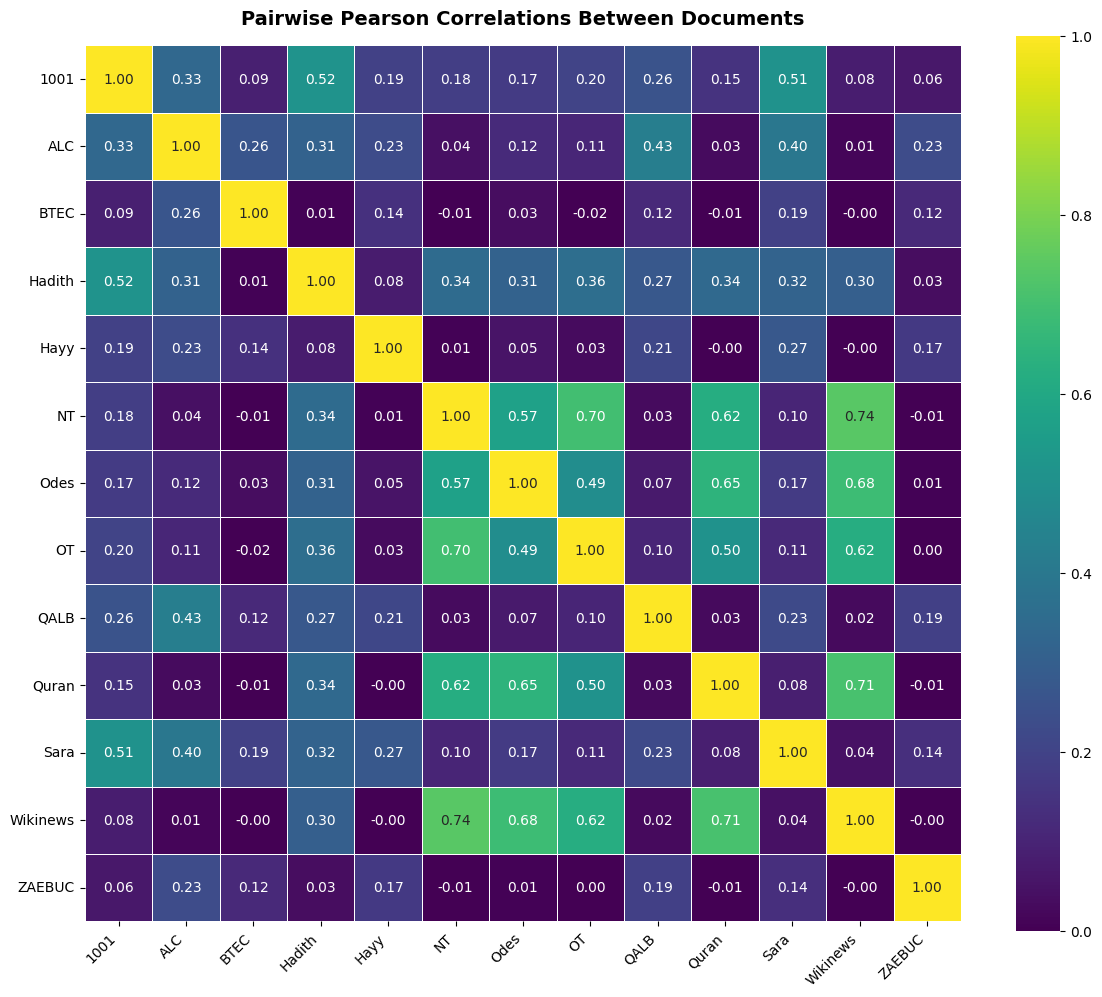

In [9]:
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

min_termfreq = 5
df_trimmed = df.loc[:, df.sum(axis=0) >= min_termfreq]
print(f"Vocab before trim: {df.shape[1]} | after trim: {df_trimmed.shape[1]}")

corr_matrix = df_trimmed.T.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt=".2f",            
    cmap="viridis",      
    vmin=0, vmax=1,      
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Pairwise Pearson Correlations Between Documents", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("analysis_images/pearson_heatmap.png", dpi=500, bbox_inches="tight")
plt.show()